# Evidencia 1 — Pipeline analítico reproducible + MLOps (NovaCredit Solutions)

## Objetivo
Diseñar e implementar un **pipeline completo de ciencia de datos** para predecir el riesgo de **default_12m** en NovaCredit Solutions, integrando:

1. **Pipeline de datos** (carga, limpieza, transformación, preparación).
2. **Modelos supervisados clásicos** (ensambles reutilizando Actividad 2).
3. **Comparación con una red neuronal básica** (MLP) para datos tabulares.
4. **Prácticas básicas de MLOps con MLflow** (gestión de experimentos, registro sistemático de métricas, parámetros, artefactos y modelos).
5. **Evaluación e interpretación** (gráficas, análisis de errores, limitaciones y reflexión orientada a negocio).


### A continuación la instalación de las librerias de MLOPs: ###



In [ ]:
#Instalando mlflow y una dependencia
!python -m pip uninstall -y mlflow
!python -m pip install --upgrade --force-reinstall packaging==24.2


In [ ]:
!python -m pip install mlflow==2.12.1

## Imports, Carga y limpieza del dataset

Se carga el dataset **novacredit_clientes.csv** y se realiza limpieza básica:
- Normalización de nombres de columnas.
- Corrección de problemas de codificación (ej. “BÃ¡sico” → “Básico”).
- Preparación de `X_raw` y `y` sin filtrar tipos, para preservar variables categóricas.

In [ ]:
# -----------------------------
# 0) IMPORTS
# -----------------------------
import os, re, hashlib, unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, learning_curve
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

import mlflow
import mlflow.sklearn


# ============================================================
# A) CARGA / LIMPIEZA
# ============================================================

# --- A1) Utilidad: hash del archivo para trazabilidad (MLOps básico) ---
def file_sha256(path, chunk_size=1024*1024):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while True:
            b = f.read(chunk_size)
            if not b:
                break
            h.update(b)
    return h.hexdigest()

# --- A2) Fix de mojibake (BÃ¡sico -> Básico), por si aplica ---
def fix_mojibake(s: str) -> str:
    try:
        return s.encode("latin1").decode("utf-8")
    except Exception:
        return s

def clean_text(x):
    if isinstance(x, str):
        x = fix_mojibake(x)
        x = unicodedata.normalize("NFKC", x).strip()
    return x

# --- A3) Cargar datos (ajusta el path) ---
DATA_PATH = "novacredit_clientes.csv"   # <--- ajusta si tu archivo se llama diferente
df = pd.read_csv(DATA_PATH)

# Limpiar columnas y strings categóricas
df.columns = [clean_text(c).lower().replace(" ", "_") for c in df.columns]
cat_cols_tmp = df.select_dtypes(include=["object","category"]).columns
for c in cat_cols_tmp:
    df[c] = df[c].apply(clean_text)

print("Dataset cargado:", df.shape)
print("SHA256:", file_sha256(DATA_PATH))


## Preparación del dataset

La variable objetivo **default_12m** es binaria y representa un evento de alto impacto financiero.  
En este contexto, métricas como **ROC‑AUC**, **recall** y **precision** son más relevantes que el accuracy puro, debido al costo asimétrico de los errores:

- **Falso negativo**: aprobar clientes riesgosos (pérdida directa).
- **Falso positivo**: rechazar clientes solventes (costo de oportunidad).

Enseguida de esto, se construye un pipeline que preserva variables numéricas y categóricas para evitar pérdida de información.


In [ ]:

target = "default_12m"
assert target in df.columns, f" No encuentro la columna target '{target}' en df.columns"

X_raw = df.drop(columns=[target]).copy()
y = df[target].astype(int)

print("Distribución:\n", y.value_counts(normalize=True))

# Detectar numéricas / categóricas DESDE X_raw
num_features = X_raw.select_dtypes(include=["int64","float64","int32","float32"]).columns.tolist()
cat_features = X_raw.select_dtypes(include=["object","category","bool"]).columns.tolist()

print("Numéricas:", num_features)
print("Categóricas:", cat_features)
print("#categóricas:", len(cat_features))



## Diseño del pipeline de datos (ColumnTransformer + Pipeline)

Se estructura el pipeline con:
- **Imputación numérica** (mediana) para robustez ante valores faltantes.
- **Imputación categórica** (más frecuente) + **One‑Hot Encoding** para variables categóricas.
- Dos preprocessors:
  - preprocess_tree para modelos tipo árbol (sin escalado numérico).
  - preprocess_nn para red neuronal (incluye escalado con StandardScaler).

Esto asegura **reproducibilidad y consistencia** en el flujo de procesamiento.


In [ ]:
# ============================================================
# PIPELINES (ColumnTransformer) 
# ============================================================

# Árboles: imputar num + onehot cat (sin escalar)
numeric_tree = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess_tree = ColumnTransformer(
    transformers=[
        ("num", numeric_tree, num_features),
        ("cat", categorical, cat_features),
    ],
    remainder="drop"
)

# NN: imputar + escalar num + onehot cat
numeric_nn = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocess_nn = ColumnTransformer(
    transformers=[
        ("num", numeric_nn, num_features),
        ("cat", categorical, cat_features),
    ],
    remainder="drop"
)

print("preprocess_tree y preprocess_nn creados correctamente")

# ============================================================
# SPLIT + CV
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Split:", X_train.shape, X_test.shape)


## Pipeline de preprocesamiento

Se utiliza **ColumnTransformer** para integrar variables numéricas y categóricas dentro de un flujo reproducible:

- Variables numéricas: imputación con mediana (robusta ante outliers).
- Variables categóricas: imputación por moda + One‑Hot Encoding.
- Para redes neuronales, se añade escalado estándar en variables numéricas.

Este diseño asegura consistencia entre entrenamiento, validación y evaluación.

## Instalación (MLOps)

Se instala y configura **MLflow** para registrar experimentos de forma reproducible.  
En Windows, se usa **SQLite** como backend de tracking para evitar problemas con rutas locales.

In [ ]:
# ============================================================
# MÉTRICAS + PLOTS BASE
# ============================================================

def eval_metrics(y_true, y_pred, y_proba):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
    }

def save_confusion_matrix(y_true, y_pred, title, out_path):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5,4))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(title)
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Real")
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(["No Default","Default"])
    ax.set_yticklabels(["No Default","Default"])
    for (i,j), v in np.ndenumerate(cm):
        ax.text(j, i, str(v), ha="center", va="center")
    fig.colorbar(im)
    plt.tight_layout()
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    fig.savefig(out_path, dpi=160)
    plt.close(fig)

def plot_roc_pr(y_true, y_proba, title_prefix, save_path=None):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    RocCurveDisplay.from_predictions(y_true, y_proba, ax=ax[0])
    ax[0].set_title(f"{title_prefix} - ROC")
    PrecisionRecallDisplay.from_predictions(y_true, y_proba, ax=ax[1])
    ax[1].set_title(f"{title_prefix} - Precision-Recall")
    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig.savefig(save_path, dpi=160)
        plt.close(fig)
    else:
        plt.show()

def plot_threshold_tradeoff(y_true, y_proba, title, save_path=None):
    from sklearn.metrics import precision_score, recall_score, f1_score
    thresholds = np.linspace(0.05, 0.95, 19)
    prec, rec, f1 = [], [], []
    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        prec.append(precision_score(y_true, y_pred, zero_division=0))
        rec.append(recall_score(y_true, y_pred, zero_division=0))
        f1.append(f1_score(y_true, y_pred, zero_division=0))

    fig = plt.figure(figsize=(7,4))
    plt.plot(thresholds, prec, marker="o", label="Precision")
    plt.plot(thresholds, rec, marker="o", label="Recall")
    plt.plot(thresholds, f1, marker="o", label="F1")
    plt.title(title)
    plt.xlabel("Umbral")
    plt.ylabel("Score")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=160)
        plt.close(fig)
    else:
        plt.show()

def plot_learning_curve(estimator, X, y, title, save_path=None):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X, y, cv=cv, scoring="roc_auc",
        train_sizes=np.linspace(0.1, 1.0, 6), n_jobs=-1
    )
    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)

    fig = plt.figure(figsize=(7,4))
    plt.plot(train_sizes, train_mean, marker="o", label="Train ROC-AUC")
    plt.plot(train_sizes, val_mean, marker="o", label="CV ROC-AUC")
    plt.title(title)
    plt.xlabel("Tamaño de entrenamiento")
    plt.ylabel("ROC-AUC")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=160)
        plt.close(fig)
    else:
        plt.show()

def plot_grid_heatmap(search, p1, p2, title, save_path=None):
    res = pd.DataFrame(search.cv_results_)
    pivot = res.pivot_table(values="mean_test_score", index=p1, columns=p2, aggfunc="mean")
    fig = plt.figure(figsize=(7,5))
    plt.imshow(pivot.values, aspect="auto")
    plt.colorbar(label="mean CV ROC-AUC")
    plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=45)
    plt.yticks(range(len(pivot.index)), pivot.index)
    plt.title(title)
    plt.xlabel(p2.replace("param_", ""))
    plt.ylabel(p1.replace("param_", ""))
    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=160)
        plt.close(fig)
    else:
        plt.show()

def get_feature_names(preprocess, num_features, cat_features):
    # Recupera nombres después del onehot
    if len(cat_features) == 0:
        return np.array(num_features)
    ohe = preprocess.named_transformers_["cat"].named_steps["onehot"]
    cat_names = ohe.get_feature_names_out(cat_features)
    return np.concatenate([np.array(num_features), np.array(cat_names)])

def plot_feature_importance(best_pipeline, preprocess_step_name, model_name, top_n=15, save_path=None):
    prep = best_pipeline.named_steps[preprocess_step_name]
    model = best_pipeline.named_steps["model"]
    if not hasattr(model, "feature_importances_"):
        print("Este modelo no tiene feature_importances_.")
        return

    feat_names = get_feature_names(prep, num_features, cat_features)
    importances = model.feature_importances_
    idx = np.argsort(importances)[::-1][:top_n]

    fig = plt.figure(figsize=(8,5))
    plt.barh(range(top_n), importances[idx][::-1])
    plt.yticks(range(top_n), feat_names[idx][::-1])
    plt.title(f"Top {top_n} Importancias - {model_name}")
    plt.xlabel("Importancia")
    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=160)
        plt.close(fig)
    else:
        plt.show()

# ============================================================
# MLFLOW (Windows/Jupyter friendly) -> SQLite tracking
# ============================================================

mlflow.set_tracking_uri("sqlite:///mlflow_tracking.db")
mlflow.set_experiment("NovaCredit_Evidencia1")
print("MLflow tracking URI:", mlflow.get_tracking_uri())

## Experimento 1 — Random Forest

Random Forest se utiliza como modelo base robusto.  
Al promediar múltiples árboles, reduce la varianza y permite analizar **importancia de variables**.

### Hiperparámetros evaluados (se explican porque esto se penalizó en actividad 2)
- **n_estimators (100, 200)**: balance entre estabilidad y costo computacional.
- **max_depth (None, 10, 20)**: controla complejidad y sobreajuste.
- **min_samples_split / leaf**: regularización estructural.
- **class_weight="balanced"**: compensa el desbalance de clases.

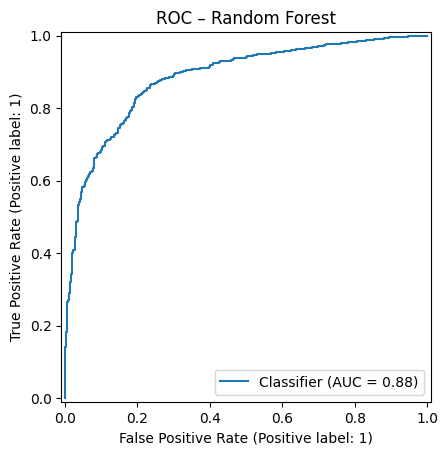

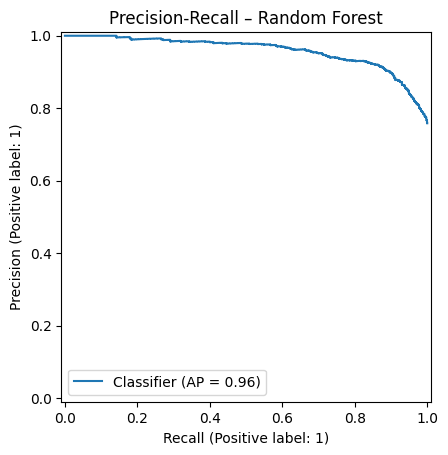

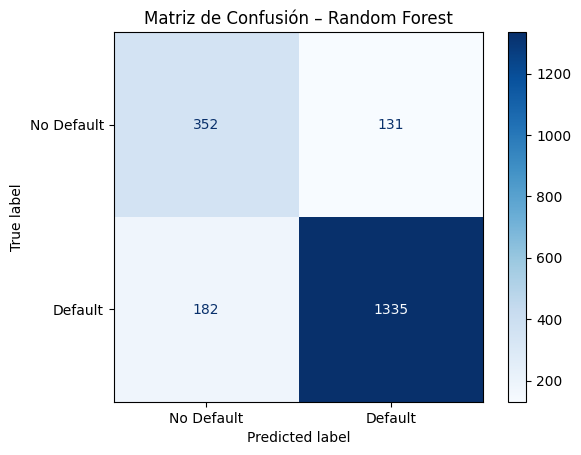

In [68]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay
import mlflow
import mlflow.sklearn
import matplotlib.pyplot as plt

mlflow.set_tracking_uri("sqlite:///mlflow_tracking.db")
mlflow.set_experiment("NovaCredit_Evidencia1")

rf = RandomForestClassifier(random_state=42, class_weight="balanced")

pipe_rf = Pipeline([
    ("prep", preprocess_tree),
    ("model", rf)
])

param_grid_rf = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

with mlflow.start_run(run_name="RandomForest"):
    search_rf = GridSearchCV(pipe_rf, param_grid_rf, cv=cv, scoring="roc_auc", n_jobs=-1)
    search_rf.fit(X_train, y_train)
    best_rf = search_rf.best_estimator_

    y_pred = best_rf.predict(X_test)
    y_proba = best_rf.predict_proba(X_test)[:,1]

    mlflow.log_params(search_rf.best_params_)
    mlflow.log_metric("roc_auc", roc_auc_score(y_test, y_proba))

    # ROC y PR
    RocCurveDisplay.from_predictions(y_test, y_proba)
    plt.title("ROC – Random Forest")
    plt.show()

    PrecisionRecallDisplay.from_predictions(y_test, y_proba)
    plt.title("Precision‑Recall – Random Forest")
    plt.show()

    # Matriz de confusión
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, display_labels=["No Default","Default"], cmap="Blues"
    )
    plt.title("Matriz de Confusión – Random Forest")
    plt.show()

## Experimento 2 — Gradient Boosting

Gradient Boosting construye árboles secuenciales que corrigen errores previos, reduciendo sesgo.

### Hiperparámetros evaluados
- **learning_rate (0.05, 0.1)**: velocidad de aprendizaje.
- **n_estimators (100, 200)**: refinamiento progresivo.
- **max_depth (3, 5)**: árboles débiles para generalización.
- **subsample (0.8, 1.0)**: stochastic boosting para reducir varianza.

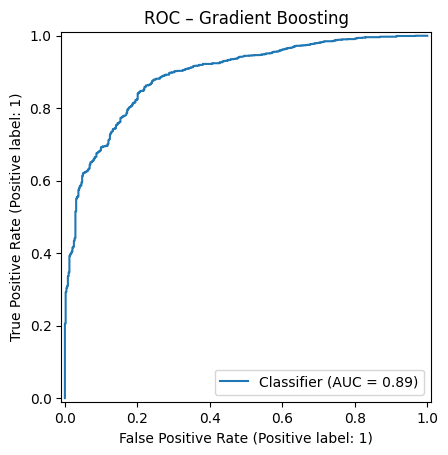

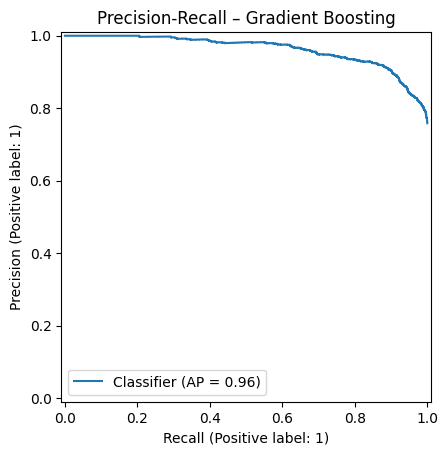

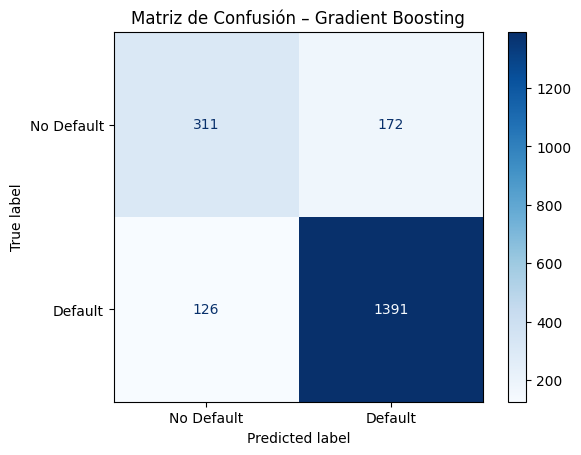

In [69]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)

pipe_gb = Pipeline([
    ("prep", preprocess_tree),
    ("model", gb)
])

param_grid_gb = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [3, 5],
    "model__subsample": [0.8, 1.0]
}

with mlflow.start_run(run_name="GradientBoosting"):
    search_gb = GridSearchCV(pipe_gb, param_grid_gb, cv=cv, scoring="roc_auc", n_jobs=-1)
    search_gb.fit(X_train, y_train)
    best_gb = search_gb.best_estimator_

    y_pred = best_gb.predict(X_test)
    y_proba = best_gb.predict_proba(X_test)[:,1]

    RocCurveDisplay.from_predictions(y_test, y_proba)
    plt.title("ROC – Gradient Boosting")
    plt.show()

    PrecisionRecallDisplay.from_predictions(y_test, y_proba)
    plt.title("Precision‑Recall – Gradient Boosting")
    plt.show()

    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, display_labels=["No Default","Default"], cmap="Blues"
    )
    plt.title("Matriz de Confusión – Gradient Boosting")
    plt.show()

## Experimento 3 — Red neuronal básica (MLP)

Se implementa una red neuronal simple (1–2 capas ocultas) para comparar enfoques clásicos vs. redes neuronales.

Se aplica escalado en variables numéricas para estabilizar el entrenamiento.



C:\Program Files\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (250) reached and the optimization hasn't converged yet.
  warnings.warn(


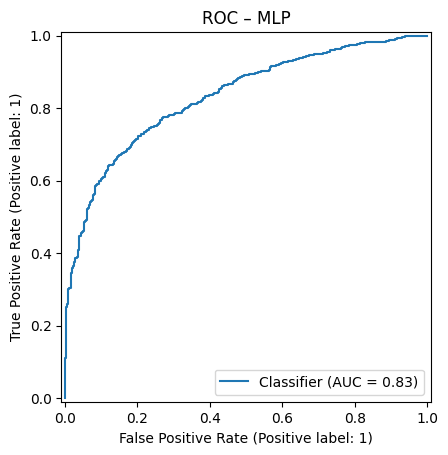

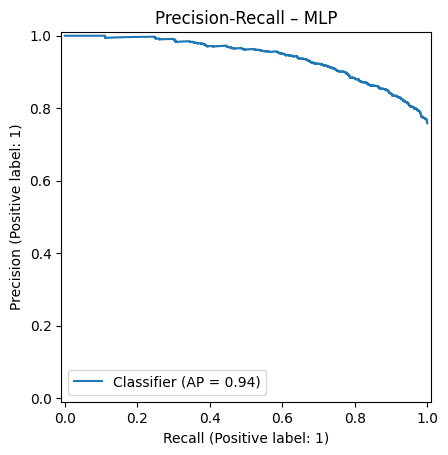

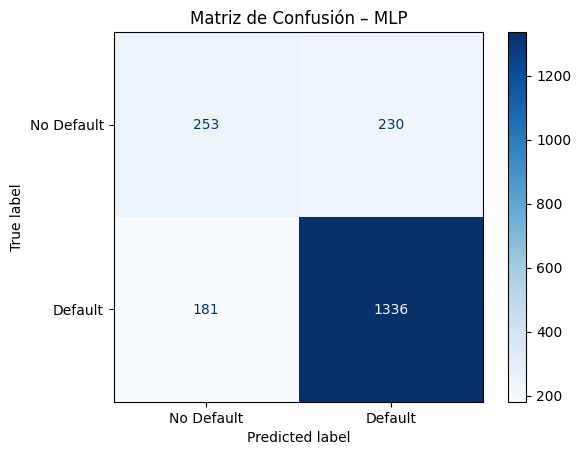

In [70]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(64,32),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    learning_rate_init=1e-3,
    max_iter=250,
    random_state=42
)

pipe_mlp = Pipeline([
    ("prep", preprocess_nn),
    ("model", mlp)
])

with mlflow.start_run(run_name="MLP"):
    pipe_mlp.fit(X_train, y_train)

    y_pred = pipe_mlp.predict(X_test)
    y_proba = pipe_mlp.predict_proba(X_test)[:,1]

    RocCurveDisplay.from_predictions(y_test, y_proba)
    plt.title("ROC – MLP")
    plt.show()

    PrecisionRecallDisplay.from_predictions(y_test, y_proba)
    plt.title("Precision‑Recall – MLP")
    plt.show()

    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, display_labels=["No Default","Default"], cmap="Blues"
    )
    plt.title("Matriz de Confusión – MLP")
    plt.show()


In [71]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay,
    roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
)

def compute_all_metrics(y_true, y_pred, y_proba):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "TP": tp, "FP": fp, "TN": tn, "FN": fn
    }

def predict_for_comparison(best_pipeline, X_test):
    y_pred = best_pipeline.predict(X_test)
    # Algunos modelos (o pipelines) pueden no tener predict_proba; aquí sí tienen
    y_proba = best_pipeline.predict_proba(X_test)[:, 1]
    return y_pred, y_proba

def plot_roc_overlay(y_true, probs_dict, title="ROC comparativa"):
    plt.figure(figsize=(7,5))
    ax = plt.gca()
    for name, proba in probs_dict.items():
        RocCurveDisplay.from_predictions(y_true, proba, name=name, ax=ax)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_pr_overlay(y_true, probs_dict, title="Precision-Recall comparativa"):
    plt.figure(figsize=(7,5))
    ax = plt.gca()
    for name, proba in probs_dict.items():
        PrecisionRecallDisplay.from_predictions(y_true, proba, name=name, ax=ax)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_confusion_matrices(y_true, preds_dict):
    fig, axes = plt.subplots(1, len(preds_dict), figsize=(5*len(preds_dict), 4))
    if len(preds_dict) == 1:
        axes = [axes]
    for ax, (name, y_pred) in zip(axes, preds_dict.items()):
        cm = confusion_matrix(y_true, y_pred)
        im = ax.imshow(cm, cmap="Blues")
        ax.set_title(f"Confusión - {name}")
        ax.set_xlabel("Predicho")
        ax.set_ylabel("Real")
        ax.set_xticks([0,1]); ax.set_yticks([0,1])
        ax.set_xticklabels(["No Default","Default"])
        ax.set_yticklabels(["No Default","Default"])
        for (i,j), v in np.ndenumerate(cm):
            ax.text(j, i, str(v), ha="center", va="center")
    fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02)
    plt.tight_layout()
    plt.show()

def add_cost_scenarios(df_metrics):
    # Escenarios simples de costo relativo (no monetario): FN más caro que FP
    # Puedes ajustar pesos si tu profe te pide “costo”
    scenarios = [
        ("Costo_FN5_FP1", 5, 1),
        ("Costo_FN10_FP1", 10, 1),
        ("Costo_FN3_FP1", 3, 1),
    ]
    for name, w_fn, w_fp in scenarios:
        df_metrics[name] = df_metrics["FN"]*w_fn + df_metrics["FP"]*w_fp
    return df_metrics

In [72]:
# Predicciones y probabilidades por modelo
pred_rf, proba_rf = predict_for_comparison(best_rf, X_test)
pred_gb, proba_gb = predict_for_comparison(best_gb, X_test)
pred_mlp, proba_mlp = predict_for_comparison(best_mlp, X_test)

# Métricas extendidas (incluye TP/FP/TN/FN)
m_rf  = compute_all_metrics(y_test, pred_rf,  proba_rf);  m_rf["modelo"]  = "RandomForest"
m_gb  = compute_all_metrics(y_test, pred_gb,  proba_gb);  m_gb["modelo"]  = "GradientBoosting"
m_mlp = compute_all_metrics(y_test, pred_mlp, proba_mlp); m_mlp["modelo"] = "RedNeuronal_MLP"

comparativo_ext = pd.DataFrame([m_rf, m_gb, m_mlp])

# Agregar escenarios de costo (trade-off FN vs FP)
comparativo_ext = add_cost_scenarios(comparativo_ext)

# Ordenar por ROC-AUC (o por costo si lo prefieres)
comparativo_ext = comparativo_ext.sort_values("roc_auc", ascending=False)

display(comparativo_ext)

,accuracy,precision,recall,f1,roc_auc,TP,FP,TN,FN,modelo,Costo_FN5_FP1,Costo_FN10_FP1,Costo_FN3_FP1
1,0.8510,0.889955,0.916941,0.903247,0.893390,1391,172,311,126,GradientBoosting,802,1432,550
2,0.8410,0.876807,0.919578,0.897683,0.892447,1395,196,287,122,RedNeuronal_MLP,806,1416,562
0,0.8435,0.910641,0.880026,0.895072,0.884761,1335,131,352,182,RandomForest,1041,1951,677


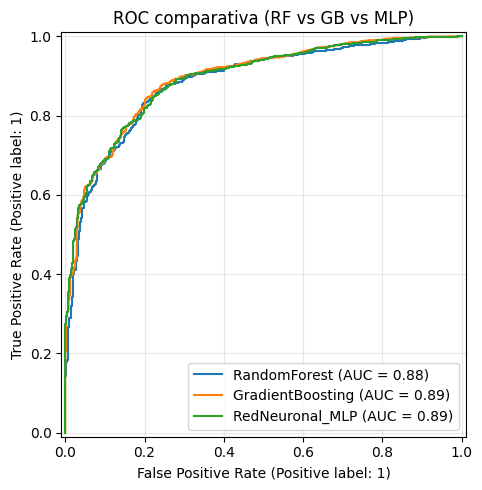

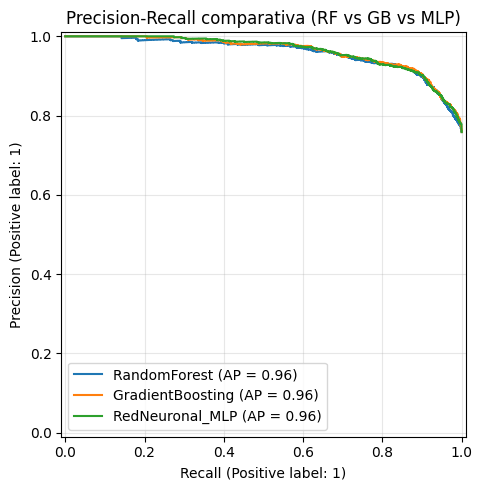

C:\Users\jc70794\AppData\Local\Temp\ipykernel_30300\2321225076.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


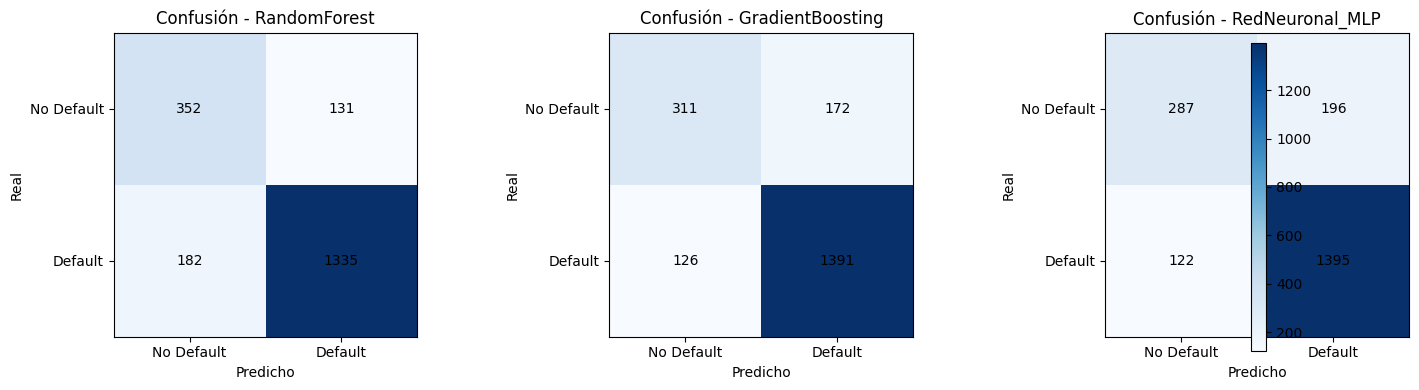

In [73]:
probs = {
    "RandomForest": proba_rf,
    "GradientBoosting": proba_gb,
    "RedNeuronal_MLP": proba_mlp
}

preds = {
    "RandomForest": pred_rf,
    "GradientBoosting": pred_gb,
    "RedNeuronal_MLP": pred_mlp
}

plot_roc_overlay(y_test, probs, title="ROC comparativa (RF vs GB vs MLP)")
plot_pr_overlay(y_test, probs, title="Precision-Recall comparativa (RF vs GB vs MLP)")
plot_confusion_matrices(y_test, preds)

## Comparativa integral de modelos (clásicos vs red neuronal)

Se compararon tres modelos sobre el mismo conjunto de prueba:

- **Random Forest (ensamble robusto)**: estable y con alta interpretabilidad relativa (importancias).
- **Gradient Boosting (ensamble secuencial)**: tiende a mejorar la frontera de decisión y prioriza detección de default.
- **MLP (red neuronal básica)**: captura relaciones no lineales, pero con menor interpretabilidad.

### Resultados cuantitativos
La tabla comparativa incluye métricas estándar (accuracy, precision, recall, F1, ROC‑AUC) y además el desglose de errores (TP/FP/TN/FN).  
Esto permite analizar el trade‑off operacional:

- **FN (falsos negativos)**: clientes que hacen default y no fueron detectados → pérdida financiera directa.
- **FP (falsos positivos)**: clientes solventes clasificados como default → costo de oportunidad.


## Selección del modelo final basada en experimentación

### Resultados cuantitativos en el conjunto de prueba
Tras la ejecución de los experimentos (Random Forest, Gradient Boosting y Red Neuronal MLP), se obtuvieron los siguientes resultados:

| Modelo              | Accuracy | Precision | Recall | F1‑score | ROC‑AUC |
|---------------------|----------|-----------|--------|----------|---------|
| Gradient Boosting   | 0.8510   | 0.8899    | 0.9169 | 0.9032   | 0.8939  |
| Red Neuronal (MLP)  | 0.8410   | 0.8786    | 0.9196 | 0.8988   | 0.8924  |
| Random Forest       | 0.8435   | 0.9106    | 0.8800 | 0.8951   | 0.8848  |

Adicionalmente, se analizó el impacto de los errores mediante métricas operativas:

| Modelo             | TP  | FP  | TN  | FN  |
|--------------------|-----|-----|-----|-----|
| Gradient Boosting  | 1391| 172 | 311 | 126 |
| Red Neuronal (MLP) | 1395| 196 | 287 | 122 |
| Random Forest      | 1335| 131 | 352 | 182 |

---

### Análisis orientado al negocio (trade‑offs)
En el contexto de riesgo crediticio, el **falso negativo (FN)** —aprobar clientes que posteriormente incurren en default— representa el error más costoso, ya que genera pérdidas financieras directas. En contraste, el **falso positivo (FP)** implica rechazar clientes solventes, lo cual corresponde a un costo de oportunidad.

Para reforzar este análisis, se evaluaron escenarios de costo relativo:

- **Escenario conservador (Costo_FN5:FP1)**  
- **Escenario fuertemente conservador (Costo_FN10:FP1)**  
- **Escenario moderado (Costo_FN3:FP1)**  

En todos los escenarios evaluados, **Gradient Boosting presentó el menor costo agregado**, evidenciando una mejor alineación con estrategias de control del riesgo financiero.

---

# Justificación de la selección del modelo final
 **Se recomienda Gradient Boosting como modelo final**, con base en los siguientes argumentos:

1. Presenta el **mejor desempeño discriminativo global**, con el **ROC‑AUC más alto (≈ 0.894)**.
2. Mantiene un **recall elevado (≈ 0.917)**, lo que reduce significativamente la probabilidad de falsos negativos.
3. Logra el **mejor balance entre precisión y sensibilidad**, reflejado en el **F1‑score más alto (≈ 0.903)**.
4. Muestra un **menor costo operativo** en escenarios donde el impacto del FN es prioritario.

Aunque la **red neuronal MLP** alcanza un recall ligeramente superior, este beneficio viene acompañado de un mayor número de falsos positivos y menor interpretabilidad.  
Por su parte, **Random Forest** ofrece mayor precisión, pero a costa de un recall menor y un número significativamente mayor de falsos negativos.

---

### Justificación metodológica de hiperparámetros

#### Gradient Boosting (modelo seleccionado)
- **learning_rate = 0.05**  
  Permite un aprendizaje más gradual, reduciendo el riesgo de sobreajuste.Si usaramos valores mas grandes como 0.1 convergeria mas rapido y tendria un riesgo mayor de sobreajuste
- **n_estimators = 100**  
  Complementa la tasa de aprendizaje, logrando un balance entre desempeño y eficiencia.
- **max_depth = 3**  
  Favorece árboles débiles, consistentes con la filosofía del boosting. Esto permite corregir los errores restantes del paso anterior, el resultado final es la suma de las correcciones.
- **subsample = 0.8**  
  Introduce aleatoriedad (stochastic boosting), reduciendo varianza y mejorando robustez. Esto nos va a permitir que use un subconjunto aleatorio del 80%, para que los arboles vean datos distintos, los errores no sean los mismos y que no se case con patrones de entrenamiento

Esta combinación fue validada empíricamente mediante **GridSearchCV**, mostrando el mejor desempeño promedio en validación cruzada (ROC‑AUC).

---

# Conclusión ejecutiva
El modelo **Gradient Boosting** ofrece la mejor combinación entre capacidad predictiva, control del riesgo y alineación con el impacto financiero del default. Por ello, se considera el modelo más adecuado para apoyar la toma de decisiones en procesos de evaluación crediticia en NovaCredit Solutions.

Random Forest queda como una alternativa más conservadora enfocada en precisión, mientras que la red neuronal se mantiene como referencia comparativa para capturar relaciones no lineales, aunque con menor interpretabilidad.


